# A1 · The Alternative Data Landscape

*Sentiment & Alternative Data track*

"Alternative data" means any information about companies or the economy that doesn't come from prices, volumes or official financial statements. This notebook maps the main kinds, explains how to judge whether a dataset is worth using, and shows with a simulation why *timing* is the property that matters most.

## 1. Motivation

Every fund sees the same prices and the same quarterly reports, so it is very hard to know something the market doesn't already know. Alternative data is an attempt to know it *earlier*: reading what customers say online before sales are reported, counting cars in store car parks from satellite images, or tracking job postings before a company announces expansion. It is now a multi-billion-dollar industry. For a club team that hasn't yet picked a data source, the first job is to understand the options, what each one costs, and how to tell a useful dataset from an expensive distraction.

## 2. Intuition

Think of alternative data as **early, noisy, partial glimpses** of numbers that will eventually become official. A company's quarterly revenue is announced months after the sales happen. Card-transaction data, web traffic or app downloads give a rough estimate of those sales *while they are happening*.

The value of such a glimpse depends on four things:

1. **Is it related to something that moves prices?** (signal)
2. **Do you get it before the market does?** (timeliness)
3. **Does it cover enough companies and enough history to test?** (coverage)
4. **Can you legally and cheaply get it, and keep getting it?** (access)

A dataset strong on signal but weak on timeliness is worthless: by the time you see it, the price has already moved.

## 3. The main kinds of alternative data

| Type | Examples | What it can tell you | Free sources for a student team |
|---|---|---|---|
| **Text: news** | headlines, articles | reactions to events, tone | GDELT project, company press releases, RSS feeds |
| **Text: filings** | 10-K, 10-Q, 8-K reports, earnings call transcripts | management tone, risk language, changes between reports | SEC EDGAR (full text, free, with timestamps) |
| **Text: social media** | Reddit, X/Twitter, StockTwits | retail attention and sentiment | Reddit API (rate-limited), archived datasets |
| **Search and web attention** | Google searches, Wikipedia page views | interest in a product or company | Google Trends, Wikimedia page-view API |
| **Consumer activity** | card transactions, app downloads, web traffic | sales before they are reported | mostly paid |
| **Geospatial** | satellite images, phone location data | store visits, factory or port activity | mostly paid |
| **Corporate activity** | job postings, patents, government contracts | expansion, innovation, revenue pipeline | USPTO patents, USAspending.gov |
| **Market-derived** | trading volume, options activity, short interest | attention, positioning | our own `volume.csv` (notebook A3) |

**The legal and ethical side.** Before collecting any data, check the website's terms of service and its `robots.txt` file, respect rate limits, and never collect personal information about individuals. "It was publicly visible" is not the same as "it is legal to scrape and use". Paid vendors exist largely because they handle these issues.

**The point-in-time problem.** Many datasets are *revised* after first publication, or are stamped with the date an event happened rather than the date the data became available. A backtest must use what was known *at the time*. Notebook A4 is entirely about this.

**A scorecard** for comparing candidate datasets before investing time in them:

| Criterion | Question to ask |
|---|---|
| Signal | Is there an economic reason it should predict returns or fundamentals? |
| Timeliness | How long after the real-world event can we see it? Before the market reacts? |
| Coverage | How many companies? How many years of history? |
| Point-in-time | Do we know exactly *when* each data point became available? |
| Cost and access | Free? Rate limits? Will access still exist next year? |
| Legal and ethical | Allowed by the terms of service? Any personal data? |

## 4. The math: why timing dominates

Suppose a piece of data predicts the next few days of returns, and its information is gradually absorbed into prices. A simple model: the data on day $t$ predicts the return on day $t+k$ with a strength that decays geometrically,
$$
R_{t+k} = \beta\,\rho^{\,k-1} s_t + \varepsilon_{t+k}, \qquad 0 < \rho < 1,\; k \ge 1 .
$$
Here $s_t$ is the signal, $\beta$ its strength on the first day, and $\rho$ how much of the effect is left each further day. The **half-life** of the information is $\ln 2 / (-\ln \rho)$ days.

If the data reaches you with a **delay** of $L$ days, you can only trade from day $t+L+1$ onwards. The predictive power you can capture falls by a factor $\rho^{L}$, *exponentially* in the delay. A dataset whose information half-life is one day loses half its value with every day of delay.

## 5. Code it

### 5.1 Simulating a signal that fades

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
plt.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 100, "axes.prop_cycle": plt.cycler(color=COLORS),
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.3, "lines.linewidth": 1.5, "font.size": 11,
})

rng = np.random.default_rng(0)
n_days, n_stocks = 2500, 50

def simulate(beta, rho, n_days=n_days, n_stocks=n_stocks, noise=0.02):
    """Returns R[t, i] = sum_k beta * rho^(k-1) * s[t-k, i] + noise, i.e. the model in Section 4."""
    s = rng.standard_normal((n_days, n_stocks))          # the alternative-data signal, one value per stock-day
    R = rng.normal(0, noise, (n_days, n_stocks))          # ordinary unpredictable returns
    for k in range(1, 30):                                # add the fading effect of past signals
        R[k:] += beta * rho ** (k - 1) * s[:-k]
    return s, R

def ic_at_delay(s, R, L):
    """Average cross-sectional correlation between the signal and the return L+1 days later."""
    ics = [np.corrcoef(s[t], R[t + L + 1])[0, 1] for t in range(n_days - L - 1)]
    return np.mean(ics)

datasets = {
    "Fast signal (half-life 1 day)": simulate(beta=0.0012, rho=0.5),      # e.g. news
    "Slow signal (half-life 13 days)": simulate(beta=0.0004, rho=0.95),  # e.g. filing language
}
delays = range(0, 11)
results = pd.DataFrame({name: [ic_at_delay(s, R, L) for L in delays] for name, (s, R) in datasets.items()},
                       index=delays)
results.round(3)

,Fast signal (half-life 1 day),Slow signal (half-life 13 days)
0,0.057,0.018
1,0.032,0.019
2,0.012,0.018
3,0.010,0.018
4,0.001,0.021
5,0.003,0.015
6,0.001,0.017
7,-0.002,0.012
8,-0.002,0.014
9,-0.002,0.008


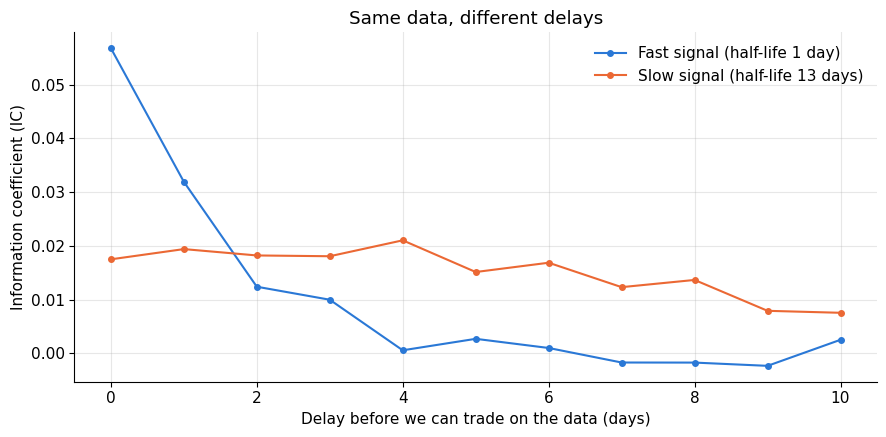

In [2]:
fig, ax = plt.subplots()
for col, c in zip(results, COLORS):
    ax.plot(results.index, results[col], marker="o", markersize=4, label=col, color=c)
ax.set_xlabel("Delay before we can trade on the data (days)")
ax.set_ylabel("Information coefficient (IC)")
ax.set_title("Same data, different delays")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

The two simulated datasets behave very differently:

- **The fast signal is the stronger one if you get it immediately** (IC ≈ 0.06). It loses about half its value with each day of delay, and after 3–4 days nothing is left. A team that sees this data a day late is competing for scraps.
- **The slow signal starts much weaker** (IC ≈ 0.02) but barely notices a delay of a few days. After a week it still has most of its value.

So the right question about a dataset is not just "does it predict returns?" but "does it predict them *at the delay at which I will actually have it*?" A slow, modest signal you can really capture beats a strong one you will always see too late.

### 5.2 What getting real data looks like

The code below shows the shape of two free, well-documented sources. It is *not run* here, because it needs internet access and the response changes over time. Both APIs ask you to identify yourself with a descriptive User-Agent.

**Wikipedia page views** (daily views of a company's article, a measure of public attention):
```python
import requests
url = ("https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/"
       "en.wikipedia/all-access/user/Nvidia/daily/20240101/20241231")
r = requests.get(url, headers={"User-Agent": "UniFinanceClub-research (your-email@uni.edu)"})
views = pd.DataFrame(r.json()["items"])[["timestamp", "views"]]
```

**SEC EDGAR filings index** (every filing a company made, with its acceptance time):
```python
cik = "0001045810"  # NVIDIA's company identifier at the SEC
r = requests.get(f"https://data.sec.gov/submissions/CIK{cik}.json",
                 headers={"User-Agent": "UniFinanceClub-research your-email@uni.edu"})
filings = pd.DataFrame(r.json()["filings"]["recent"])[["form", "filingDate", "acceptanceDateTime"]]
```
Note `acceptanceDateTime`: the exact time the filing became public. That is the timestamp a backtest needs (A4).

## 6. Takeaways and where it breaks

- **Alternative data is about getting information earlier**, not about having more data.
- **Judge datasets on signal, timeliness, coverage, point-in-time quality, cost and legality** before writing any model.
- **Delay kills fast signals.** The faster the market absorbs a kind of information, the more precisely you need to know *when* you could have seen it.
- **Where it breaks:** popular alternative datasets get crowded. Once many funds buy the same data, its edge shrinks, just like the pairs trades in S2. Short histories (many datasets start after 2015) make proper testing hard.
- **For a student team, the realistic edge is depth, not speed.** Funds win on speed. A club team is better off studying slow-moving signals (filing language, attention over weeks) where a one-day delay costs little.

**What you could build:** a dataset evaluation for the team's first project. Pick two or three candidate free sources, fill in the scorecard for each, and collect a small sample to check timestamps and coverage before committing to one.